Title
# Market Basket Analysis - Product Association & Cross-Sell Insights

## Project Overview
This project uses Market Basket Analysis to identify products that are frequently purchased together. The Apriori algorithm is used to generate frequent itemsets and association rules, which help businesses improve cross-selling strategies and product placement.

## Objective

The objective of this project is to:

- Discover frequently purchased product combinations.
- Generate association rules using the Apriori algorithm.
- Calculate Support, Confidence, and Lift metrics.
- Provide actionable business recommendations for cross-selling and promotions.


## Technologies Used

- Python
- Pandas
- mlxtend
- Matplotlib
- Seaborn
- Jupyter Notebook

## Dataset Information

Dataset Name: Market Basket Optimisation Dataset

Source: Kaggle

Dataset Statistics:
- Total Transactions: 7501
- Total Unique Products: 120

The dataset contains customer transaction records used for identifying product associations.

## Project Workflow

1. Data Loading
2. Data Preparation
3. Transaction Encoding
4. Frequent Itemset Generation (Apriori)
5. Association Rule Mining
6. Data Visualization
7. Business Insights and Recommendations

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

In [2]:
dataset = pd.read_csv("Market_Basket_Optimisation.csv", header=None)

print(dataset.shape)

(7501, 20)


In [3]:
transactions = dataset.fillna('').values.tolist()

transactions = [[item for item in row if item != '']
                for row in transactions]

print(len(transactions))
print(transactions[0])

7501
['shrimp', 'almonds', 'avocado', 'vegetables mix', 'green grapes', 'whole weat flour', 'yams', 'cottage cheese', 'energy drink', 'tomato juice', 'low fat yogurt', 'green tea', 'honey', 'salad', 'mineral water', 'salmon', 'antioxydant juice', 'frozen smoothie', 'spinach', 'olive oil']


In [4]:
te = TransactionEncoder()

basket = pd.DataFrame(
    te.fit_transform(transactions),
    columns=te.columns_
)

print(basket.shape)

(7501, 120)


In [5]:
from mlxtend.frequent_patterns import apriori

frequent_itemsets = apriori(
    basket,
    min_support=0.01,
    use_colnames=True
)

print(frequent_itemsets.shape)
frequent_itemsets.head()

(257, 2)


,support,itemsets
0,0.020397,frozenset({almonds})
1,0.033329,frozenset({avocado})
2,0.010799,frozenset({barbecue sauce})
3,0.014265,frozenset({black tea})
4,0.011465,frozenset({body spray})


In [6]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1
)

rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({avocado}),frozenset({mineral water}),0.033329,0.238368,0.011598,0.348000,1.459926,1.0,0.003654,1.168147,0.325896,0.044593,0.143943,0.198329
1,frozenset({mineral water}),frozenset({avocado}),0.238368,0.033329,0.011598,0.048658,1.459926,1.0,0.003654,1.016113,0.413630,0.044593,0.015857,0.198329
2,frozenset({cake}),frozenset({burgers}),0.081056,0.087188,0.011465,0.141447,1.622319,1.0,0.004398,1.063198,0.417434,0.073129,0.059442,0.136473
3,frozenset({burgers}),frozenset({cake}),0.087188,0.081056,0.011465,0.131498,1.622319,1.0,0.004398,1.058080,0.420238,0.073129,0.054892,0.136473
4,frozenset({burgers}),frozenset({chocolate}),0.087188,0.163845,0.017064,0.195719,1.194537,1.0,0.002779,1.039630,0.178411,0.072934,0.038120,0.149934


In [7]:
rules.sort_values(
    by="lift",
    ascending=False
).head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
214,frozenset({herb & pepper}),frozenset({ground beef}),0.049460,0.098254,0.015998,0.323450,3.291994,1.0,0.011138,1.332860,0.732460,0.121457,0.249734,0.243136
215,frozenset({ground beef}),frozenset({herb & pepper}),0.098254,0.049460,0.015998,0.162822,3.291994,1.0,0.011138,1.135410,0.772094,0.121457,0.119261,0.243136
387,frozenset({ground beef}),"frozenset({spaghetti, mineral water})",0.098254,0.059725,0.017064,0.173677,2.907928,1.0,0.011196,1.137902,0.727602,0.121097,0.121190,0.229696
382,"frozenset({spaghetti, mineral water})",frozenset({ground beef}),0.059725,0.098254,0.017064,0.285714,2.907928,1.0,0.011196,1.262445,0.697788,0.121097,0.207886,0.229696
398,frozenset({olive oil}),"frozenset({spaghetti, mineral water})",0.065858,0.059725,0.010265,0.155870,2.609786,1.0,0.006332,1.113898,0.660314,0.089017,0.102252,0.163873
395,"frozenset({spaghetti, mineral water})",frozenset({olive oil}),0.059725,0.065858,0.010265,0.171875,2.609786,1.0,0.006332,1.128021,0.656007,0.089017,0.113491,0.163873
193,frozenset({tomatoes}),frozenset({frozen vegetables}),0.068391,0.095321,0.016131,0.235867,2.474464,1.0,0.009612,1.183930,0.639616,0.109304,0.155355,0.202549
192,frozenset({frozen vegetables}),frozenset({tomatoes}),0.095321,0.068391,0.016131,0.169231,2.474464,1.0,0.009612,1.121381,0.658656,0.109304,0.108243,0.202549
189,frozenset({shrimp}),frozenset({frozen vegetables}),0.071457,0.095321,0.016664,0.233209,2.446574,1.0,0.009853,1.179825,0.636767,0.111012,0.152417,0.204017
188,frozenset({frozen vegetables}),frozenset({shrimp}),0.095321,0.071457,0.016664,0.174825,2.446574,1.0,0.009853,1.125268,0.653563,0.111012,0.111323,0.204017


In [8]:
rules.to_csv("Association_Rules.csv", index=False)

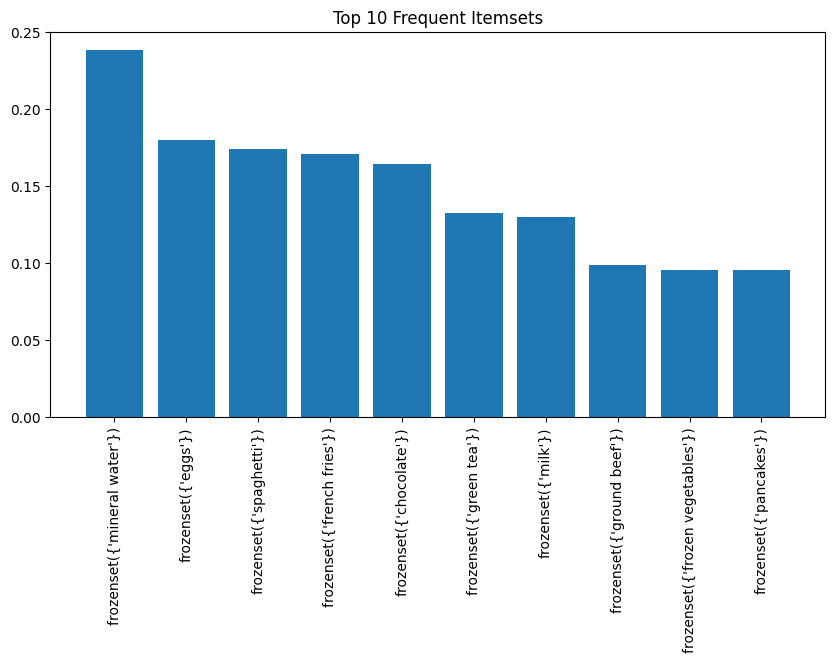

In [9]:
import matplotlib.pyplot as plt

top_items = frequent_itemsets.sort_values(
    'support',
    ascending=False
).head(10)

plt.figure(figsize=(10,5))
plt.bar(
    top_items['itemsets'].astype(str),
    top_items['support']
)
plt.xticks(rotation=90)
plt.title("Top 10 Frequent Itemsets")
plt.show()

In [10]:
rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1
)

print(rules.shape)
rules.head()

(406, 14)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({avocado}),frozenset({mineral water}),0.033329,0.238368,0.011598,0.348000,1.459926,1.0,0.003654,1.168147,0.325896,0.044593,0.143943,0.198329
1,frozenset({mineral water}),frozenset({avocado}),0.238368,0.033329,0.011598,0.048658,1.459926,1.0,0.003654,1.016113,0.413630,0.044593,0.015857,0.198329
2,frozenset({cake}),frozenset({burgers}),0.081056,0.087188,0.011465,0.141447,1.622319,1.0,0.004398,1.063198,0.417434,0.073129,0.059442,0.136473
3,frozenset({burgers}),frozenset({cake}),0.087188,0.081056,0.011465,0.131498,1.622319,1.0,0.004398,1.058080,0.420238,0.073129,0.054892,0.136473
4,frozenset({burgers}),frozenset({chocolate}),0.087188,0.163845,0.017064,0.195719,1.194537,1.0,0.002779,1.039630,0.178411,0.072934,0.038120,0.149934


In [11]:
top_rules = rules.sort_values(
    by="lift",
    ascending=False
)

top_rules.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
214,frozenset({herb & pepper}),frozenset({ground beef}),0.049460,0.098254,0.015998,0.323450,3.291994,1.0,0.011138,1.332860,0.732460,0.121457,0.249734,0.243136
215,frozenset({ground beef}),frozenset({herb & pepper}),0.098254,0.049460,0.015998,0.162822,3.291994,1.0,0.011138,1.135410,0.772094,0.121457,0.119261,0.243136
387,frozenset({ground beef}),"frozenset({spaghetti, mineral water})",0.098254,0.059725,0.017064,0.173677,2.907928,1.0,0.011196,1.137902,0.727602,0.121097,0.121190,0.229696
382,"frozenset({spaghetti, mineral water})",frozenset({ground beef}),0.059725,0.098254,0.017064,0.285714,2.907928,1.0,0.011196,1.262445,0.697788,0.121097,0.207886,0.229696
398,frozenset({olive oil}),"frozenset({spaghetti, mineral water})",0.065858,0.059725,0.010265,0.155870,2.609786,1.0,0.006332,1.113898,0.660314,0.089017,0.102252,0.163873
395,"frozenset({spaghetti, mineral water})",frozenset({olive oil}),0.059725,0.065858,0.010265,0.171875,2.609786,1.0,0.006332,1.128021,0.656007,0.089017,0.113491,0.163873
193,frozenset({tomatoes}),frozenset({frozen vegetables}),0.068391,0.095321,0.016131,0.235867,2.474464,1.0,0.009612,1.183930,0.639616,0.109304,0.155355,0.202549
192,frozenset({frozen vegetables}),frozenset({tomatoes}),0.095321,0.068391,0.016131,0.169231,2.474464,1.0,0.009612,1.121381,0.658656,0.109304,0.108243,0.202549
189,frozenset({shrimp}),frozenset({frozen vegetables}),0.071457,0.095321,0.016664,0.233209,2.446574,1.0,0.009853,1.179825,0.636767,0.111012,0.152417,0.204017
188,frozenset({frozen vegetables}),frozenset({shrimp}),0.095321,0.071457,0.016664,0.174825,2.446574,1.0,0.009853,1.125268,0.653563,0.111012,0.111323,0.204017


In [12]:
rules.to_csv("Association_Rules.csv", index=False)

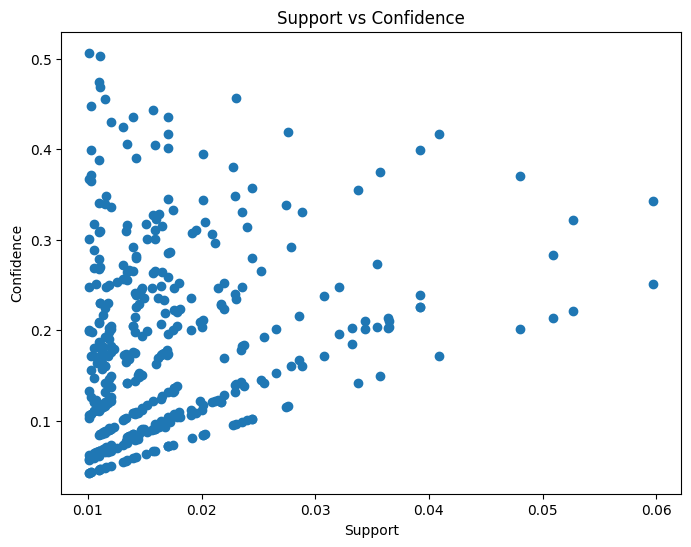

In [13]:
plt.figure(figsize=(8,6))
plt.scatter(
    rules['support'],
    rules['confidence']
)

plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Support vs Confidence')
plt.show()

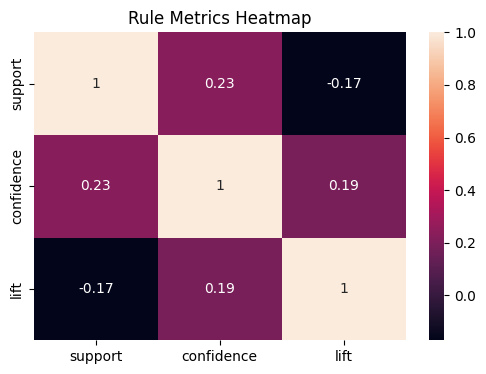

In [14]:
import seaborn as sns

plt.figure(figsize=(6,4))

sns.heatmap(
    rules[['support','confidence','lift']].corr(),
    annot=True
)

plt.title('Rule Metrics Heatmap')
plt.show()

In [15]:
rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1
)

rules.to_csv("Association_Rules.csv", index=False)

rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({avocado}),frozenset({mineral water}),0.033329,0.238368,0.011598,0.348000,1.459926,1.0,0.003654,1.168147,0.325896,0.044593,0.143943,0.198329
1,frozenset({mineral water}),frozenset({avocado}),0.238368,0.033329,0.011598,0.048658,1.459926,1.0,0.003654,1.016113,0.413630,0.044593,0.015857,0.198329
2,frozenset({cake}),frozenset({burgers}),0.081056,0.087188,0.011465,0.141447,1.622319,1.0,0.004398,1.063198,0.417434,0.073129,0.059442,0.136473
3,frozenset({burgers}),frozenset({cake}),0.087188,0.081056,0.011465,0.131498,1.622319,1.0,0.004398,1.058080,0.420238,0.073129,0.054892,0.136473
4,frozenset({burgers}),frozenset({chocolate}),0.087188,0.163845,0.017064,0.195719,1.194537,1.0,0.002779,1.039630,0.178411,0.072934,0.038120,0.149934


In [16]:
basket.to_csv("Basket_Matrix.csv")

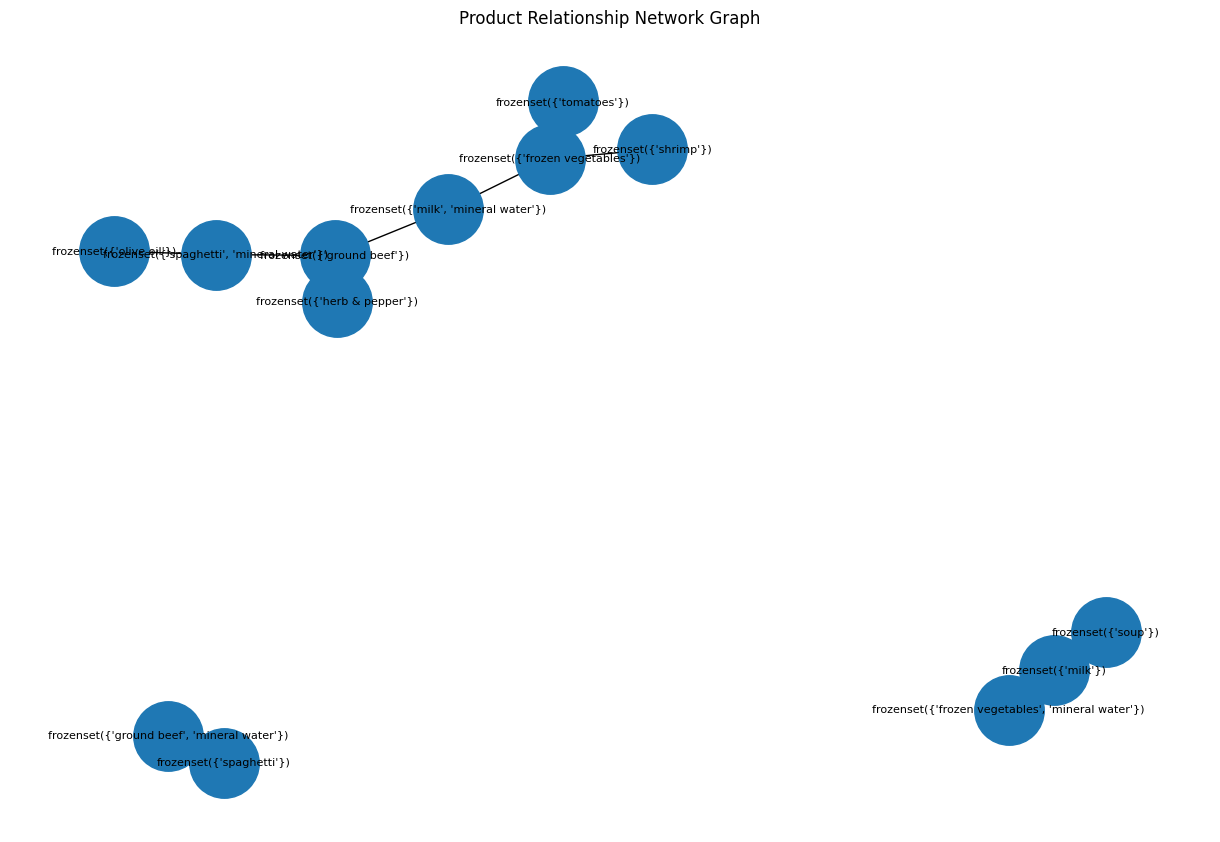

In [17]:

# Read association rules
rules = pd.read_csv("Association_Rules.csv")

# Create graph
G = nx.Graph()

# Add top 20 rules
top_rules = rules.sort_values(by='lift', ascending=False).head(20)

for _, row in top_rules.iterrows():
    G.add_edge(str(row['antecedents']),
               str(row['consequents']),
               weight=row['lift'])

# Draw graph
plt.figure(figsize=(12,8))
pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2500,
    font_size=8
)

plt.title("Product Relationship Network Graph")
plt.show()

## Conclusion

Market Basket Analysis successfully identified product associations and customer purchasing patterns. The generated association rules can be used for cross-selling, product placement optimization, and targeted marketing campaigns.